<a href="https://colab.research.google.com/github/Danilzs/Analise-Sus/blob/main/An%C3%A1lise_Sus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import html

base = pd.read_csv(
    '/Base.csv',
    skiprows=1
)

# Corrigindo nomes das colunas
base.columns = [html.unescape(c) for c in base.columns]

# Corrigindo textos das células
base = base.apply(
    lambda col: col.map(
        lambda x: html.unescape(x)
        if isinstance(x, str)
        else x
    )
)

base.head()

,Município [-],Código [-],Gentílico [-],Prefeito [2025],Área Territorial - km² [2025],População no último censo - pessoas [2022],Densidade demográfica - hab/km² [2022],População estimada - pessoas [2025],Escolarização <span>6 a 14 anos</span> - % [2022],IDHM <span>Índice de desenvolvimento humano municipal</span> [2010],Mortalidade infantil - óbitos por mil nascidos vivos [2023],Total de receitas brutas realizadas - R$ [2024],Total de despesas brutas empenhadas - R$ [2024],PIB per capita - R$ [2023],Unnamed: 14
0,Abaiara,2300101,abaiarense,ANGELO FURTADO SAMPAIO,180.833,10038,55.51,10269,99.69,0.628,-,62478227.64,55577854.04,14318.54,NaN
1,Acarape,2300150,acarapense,FRANCISCO EDILBERTO BESERRA BARROSO,129.767,14027,107.90,14340,97.64,0.606,-,99314234.62,93260342.18,15717.86,NaN
2,Acaraú,2300200,acarauense,ANA FLÁVIA RIBEIRO MONTEIRO,842.469,65264,77.47,69317,99.45,0.601,7.79,355004235.11,342565319.59,19156.82,NaN
3,Acopiara,2300309,acopiarense,FRANCISCO VILMAR FELIX MARTINS,2254.279,44962,19.95,45937,99.45,0.595,4.42,232541466.38,226807403.04,15424.91,NaN
4,Aiuaba,2300408,aiuabense,JOSE MORAES FEITOSA,2438.563,14076,5.77,14115,98.87,0.569,8.2,89022174.43,85657480.56,12011.64,NaN


In [4]:
base = base[
[
'Município [-]',
'Código [-]',
'População no último censo - pessoas [2022]',
'IDHM <span>Índice de desenvolvimento humano municipal</span> [2010]',
'Densidade demográfica - hab/km² [2022]'
]
]

#peguei somente as colunas necessarias

In [5]:
base.columns = [
'MUNICIPIO',
'CODIGO',
'POPULACAO',
'IDH',
'DENSIDADE'
]

base['MUNICIPIO'] = (
    base['MUNICIPIO']
    .str.upper()
    .str.strip()
)

In [6]:
base.head()

,MUNICIPIO,CODIGO,POPULACAO,IDH,DENSIDADE
0,ABAIARA,2300101,10038,0.628,55.51
1,ACARAPE,2300150,14027,0.606,107.90
2,ACARAÚ,2300200,65264,0.601,77.47
3,ACOPIARA,2300309,44962,0.595,19.95
4,AIUABA,2300408,14076,0.569,5.77


In [7]:
base.to_csv(
    '/content/base_ibge_limpa.csv',
    index=False,
    encoding='utf-8'
)

In [9]:
import pandas as pd

sus = pd.read_csv('/content/sus.txt', sep=',')

sus.head()

,ID,MUNICÍPIO,PRIMEIRO_NOME
0,1,ABAIARA ...,ADRIANA
1,2,ABAIARA ...,ADRIANA
2,3,ABAIARA ...,ALINE
3,4,ABAIARA ...,ALZENIR
4,5,ABAIARA ...,ANA


In [10]:
sus['MUNICÍPIO'] = (
    sus['MUNICÍPIO']
    .str.upper()
    .str.strip()
)

sus.columns = [
    'ID',
    'MUNICIPIO',
    'PRIMEIRO_NOME'
]

sus.head()

,ID,MUNICIPIO,PRIMEIRO_NOME
0,1,ABAIARA,ADRIANA
1,2,ABAIARA,ADRIANA
2,3,ABAIARA,ALINE
3,4,ABAIARA,ALZENIR
4,5,ABAIARA,ANA


In [11]:
import unicodedata

def remover_acentos(txt):
    if isinstance(txt, str):
        return ''.join(
            c for c in unicodedata.normalize('NFKD', txt)
            if not unicodedata.combining(c)
        )
    return txt

sus['MUNICIPIO'] = (
    sus['MUNICIPIO']
    .str.upper()
    .str.strip()
    .apply(remover_acentos)
)

base['MUNICIPIO'] = (
    base['MUNICIPIO']
    .str.upper()
    .str.strip()
    .apply(remover_acentos)
)

In [12]:
sus['MUNICIPIO'] = sus['MUNICIPIO'].replace(
    {'ITAPAGE':'ITAPAJE'}
)
#Na base do ibge tava escrito Itapaje e na do Sus, Itapage, então corrigi.

In [15]:
final = sus.merge(
    base,
    on='MUNICIPIO',
    how='left'
)

final.head()

,ID,MUNICIPIO,PRIMEIRO_NOME,CODIGO,POPULACAO,IDH,DENSIDADE
0,1,ABAIARA,ADRIANA,2300101,10038,0.628,55.51
1,2,ABAIARA,ADRIANA,2300101,10038,0.628,55.51
2,3,ABAIARA,ALINE,2300101,10038,0.628,55.51
3,4,ABAIARA,ALZENIR,2300101,10038,0.628,55.51
4,5,ABAIARA,ANA,2300101,10038,0.628,55.51


In [16]:
print("Total registros:", len(final))
print("Municípios únicos:", final['MUNICIPIO'].nunique())

final.describe(include='all')

Total registros: 204579
Municípios únicos: 184


,ID,MUNICIPIO,PRIMEIRO_NOME,CODIGO,POPULACAO,IDH,DENSIDADE
count,204579.000000,204579,204578,204579,204579,204579,204579
unique,NaN,184,16531,184,184,101,178
top,NaN,FORTALEZA,MARIA,2304400,2428708,0.606,7775.52
freq,NaN,9364,48240,9364,9364,13117,9364
mean,102290.000000,NaN,NaN,NaN,NaN,NaN,NaN
std,59057.014698,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,51145.500000,NaN,NaN,NaN,NaN,NaN,NaN
50%,102290.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,153434.500000,NaN,NaN,NaN,NaN,NaN,NaN


A base contém 204.579 registros de atendimentos distribuídos entre 184 municípios únicos, cobrindo todos os municípios do Ceará após o enriquecimento com dados populacionais do IBGE.

In [25]:


#Quantidade de atendimentos por municipio
atendimentos = (
    final.groupby('MUNICIPIO')
    .size()
    .reset_index(name='ATENDIMENTOS')
)

atendimentos = atendimentos.sort_values(
    'ATENDIMENTOS',
    ascending=False
)

atendimentos.head(10)

,MUNICIPIO,ATENDIMENTOS
58,FORTALEZA,9364
87,ITAPIPOCA,7620
98,JUAZEIRO DO NORTE,4495
103,MARACANAU,4403
174,TRAIRI,4377
148,QUIXADA,4018
173,TIANGUA,3926
166,SOBRAL,3789
104,MARANGUAPE,3728
89,ITAREMA,3080


In [26]:
atendimentos = (
    final.groupby(
        ['MUNICIPIO','POPULACAO','IDH','DENSIDADE']
    )
    .size()
    .reset_index(name='ATENDIMENTOS')
)



In [27]:
atendimentos['POPULACAO'] = (
    atendimentos['POPULACAO']
    .astype(str)
    .str.replace('.', '', regex=False)   # remove separador milhar
    .str.replace(',', '.', regex=False)  # troca vírgula decimal
)

atendimentos['POPULACAO'] = pd.to_numeric(
    atendimentos['POPULACAO'],
    errors='coerce'
)
#converti populacao pra numero (tava em string)

In [24]:
inconsistencias = atendimentos[
    atendimentos['ATENDIMENTOS']
    >
    atendimentos['POPULACAO']
]

inconsistencias

,MUNICIPIO,POPULACAO,IDH,DENSIDADE,ATENDIMENTOS


In [28]:
atendimentos['ATEND_100K'] = (
    atendimentos['ATENDIMENTOS']
    *100000 /
    atendimentos['POPULACAO']
)

atendimentos.sort_values(
    'ATEND_100K',
    ascending=False
)[
['MUNICIPIO',
 'ATENDIMENTOS',
 'POPULACAO',
 'ATEND_100K']
].head(10)

#calculando as 10 maiores taxas proporcionais de atendimento (por 100mil habitantes)

,MUNICIPIO,ATENDIMENTOS,POPULACAO,ATEND_100K
137,PENAFORTE,753,8972,8392.777530
172,TEJUCUOCA,1343,17154,7829.077766
90,ITATIRA,1591,20424,7789.855072
156,SALITRE,1280,16633,7695.545001
179,URUBURETAMA,1524,20189,7548.665115
174,TRAIRI,4377,58415,7492.938458
159,SANTANA DO CARIRI,1234,16954,7278.518344
89,ITAREMA,3080,42957,7169.960658
125,OROS,1303,19675,6622.617535
88,ITAPIUNA,1178,17841,6602.768903


In [29]:
#10 menores taxas
baixo = atendimentos.sort_values(
    'ATEND_100K'
)

baixo[['MUNICIPIO','ATEND_100K']].head(10)

,MUNICIPIO,ATEND_100K
58,FORTALEZA,385.554789
54,ERERE,602.409639
55,EUSEBIO,690.306054
43,CAUCAIA,823.776495
70,HORIZONTE,836.064477
85,ITAITINGA,844.547564
53,DEPUTADO IRAPUAN PINHEIRO,985.221675
12,ARACATI,1027.784804
76,IGUATU,1236.947300
22,BARBALHA,1288.766276


In [30]:
#os 10 maiores em valor absoluto

atendimentos.sort_values(
    'ATENDIMENTOS',
    ascending=False
)[
['MUNICIPIO',
 'ATENDIMENTOS',
 'POPULACAO',
 'ATEND_100K']
].head(10)

,MUNICIPIO,ATENDIMENTOS,POPULACAO,ATEND_100K
58,FORTALEZA,9364,2428708,385.554789
87,ITAPIPOCA,7620,131123,5811.337447
98,JUAZEIRO DO NORTE,4495,286120,1571.019153
103,MARACANAU,4403,234509,1877.539881
174,TRAIRI,4377,58415,7492.938458
148,QUIXADA,4018,84168,4773.785762
173,TIANGUA,3926,81506,4816.823301
166,SOBRAL,3789,203023,1866.291011
104,MARANGUAPE,3728,105093,3547.334266
89,ITAREMA,3080,42957,7169.960658


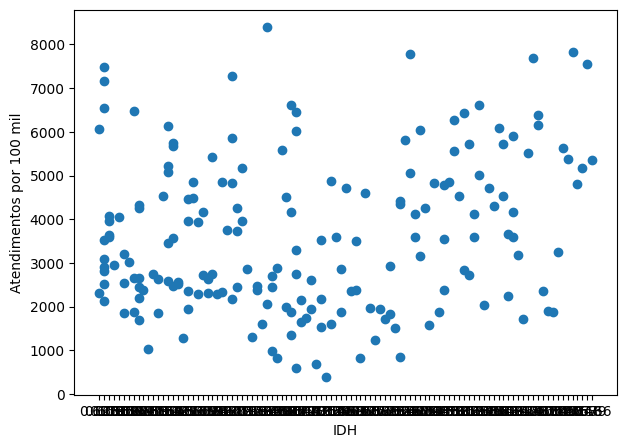

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(
    atendimentos['IDH'],
    atendimentos['ATEND_100K']
)

plt.xlabel('IDH')
plt.ylabel('Atendimentos por 100 mil')

plt.show()

In [32]:
atendimentos[
['IDH','ATEND_100K']
].corr()

,IDH,ATEND_100K
IDH,1.000000,-0.392025
ATEND_100K,-0.392025,1.000000


In [33]:
final['LOCALIZACAO'] = (
    final['MUNICIPIO']
    + ', Ceará, Brasil'
)

In [34]:
final.to_csv(
    'base_enriquecida.csv',
    index=False,
    encoding='utf-8-sig'
)